### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import datetime as dt

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.ion()

plt.style.use('default')

### Stock Returns Data

In [2]:
import os
from pathlib import Path

# Load all PSX stock data
data_path = Path(r"d:\Shafqat\Stock-Market-Prediction-Portfolio-Optimization-main\Data\Stocks (part of the experimental set)")
csv_files = sorted([f for f in data_path.glob("*.csv")])

# Map full filenames to simple ticker symbols
ticker_mapping = {
    'Fatima Fertilizer Company Stock Price History.csv': 'FATF',
    'Fauji Fertilizer Company Stock Price History.csv': 'FFC',
    'FrieslandCampina Stock Price History.csv': 'FCPL',
    'Habib Bank Stock Price History.csv': 'HBL',
    'Lucky Cement Stock Price History.csv': 'LUCK',
    'Mari Petroleum Company Stock Price History.csv': 'MARI',
    'MCB Bank Stock Price History.csv': 'MCB',
    'National Bank of Pakistan Stock Price History (1).csv': 'NBP',
    'Pakistan Petroleum Stock Price History.csv': 'PPL',
    'United Bank Stock Price History.csv': 'UBL'
}

# Load and combine all price data
price_data = {}
for csv_file in csv_files:
    ticker = ticker_mapping.get(csv_file.name, csv_file.stem)
    df = pd.read_csv(csv_file)
    df['Date'] = pd.to_datetime(df['Date'])
    # Convert Price to numeric, handling any non-numeric values
    df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
    price_data[ticker] = df.set_index('Date')['Price']

# Create combined price dataframe
prices = pd.DataFrame(price_data)
prices = prices.sort_index()

# Remove rows with missing data
prices = prices.dropna()

# Compute daily percentage returns
returns = prices.pct_change().dropna()
returns

,FATF,FFC,FCPL,HBL,LUCK,MARI,MCB,NBP,PPL,UBL
Date,,,,,,,,,,
2016-06-01,0.126036,0.010989,-0.010967,0.122507,0.089226,0.029576,0.054203,0.056866,0.020868,0.045132
2016-07-01,0.005891,-0.010435,-0.106183,0.099036,0.146059,0.072837,0.008203,0.103806,0.020709,0.047818
2016-08-01,-0.043924,-0.025835,-0.027337,0.002725,-0.064734,-0.007282,-0.048907,0.136677,0.039265,0.101629
2016-09-01,0.094334,-0.062782,0.032481,0.017964,-0.023792,-0.013994,0.053763,0.006757,-0.004796,-0.026638
2016-10-01,-0.076686,0.005775,-0.008260,0.009050,-0.005908,0.031018,-0.027211,-0.017258,-0.089541,0.013583
...,...,...,...,...,...,...,...,...,...,...
2025-12-01,0.018337,0.007728,0.019696,0.046600,0.036487,0.016254,0.054712,0.125529,0.118896,0.120202
2026-01-01,0.128092,-0.003623,-0.008328,0.063356,0.015096,-0.008130,0.073541,0.108390,0.177415,0.146800
2026-02-01,-0.045021,-0.061114,-0.066947,-0.097005,-0.124344,-0.147873,-0.024651,-0.025742,-0.218468,-0.096772


In [3]:
assets= returns.columns
for i in assets:
    print(i)
    print(np.mean(returns[i]))
    print()

FATF
0.01619651947547561

FFC
0.015466407956538584

FCPL
0.0009718588880098733

HBL
0.009096945133003848

LUCK
0.005998552642495211

MARI
0.022316787463830253

MCB
0.0072527932166549115

NBP
0.016146007876878043

PPL
0.012115364351505271

UBL
0.01710848507042627



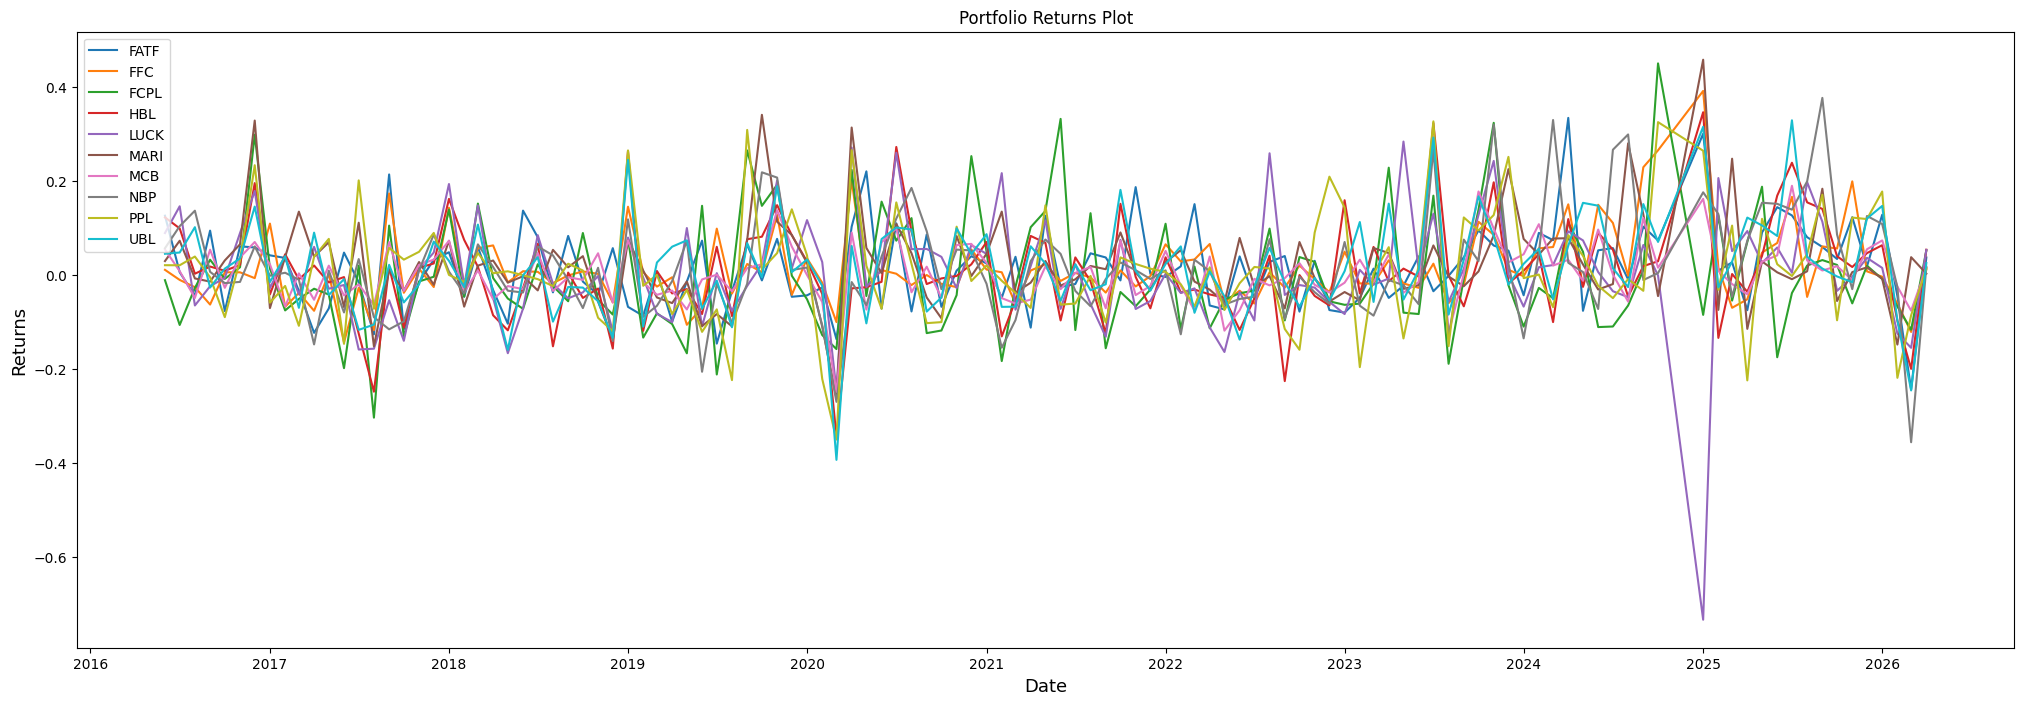

In [4]:
### Plotting Predicted Returns
plt.figure(figsize= (25,8))
plt.title('Portfolio Returns Plot')

for c in assets:
    plt.plot(returns[c], label= c)

plt.xlabel('Date', fontsize= 13)
plt.ylabel('Returns', fontsize= 13)
plt.legend(returns.columns.values, loc= 'upper left')

In [5]:
### Log Returns
logReturns= np.log(1 + returns)
logReturns

,FATF,FFC,FCPL,HBL,LUCK,MARI,MCB,NBP,PPL,UBL
Date,,,,,,,,,,
2016-06-01,0.118704,0.010929,-0.011028,0.115565,0.085467,0.029147,0.052785,0.055308,0.020653,0.044144
2016-07-01,0.005874,-0.010490,-0.112254,0.094433,0.136329,0.070306,0.008169,0.098764,0.020497,0.046710
2016-08-01,-0.044918,-0.026174,-0.027718,0.002721,-0.066924,-0.007309,-0.050143,0.128109,0.038514,0.096790
2016-09-01,0.090146,-0.064839,0.031964,0.017805,-0.024080,-0.014093,0.052368,0.006734,-0.004808,-0.026999
2016-10-01,-0.079786,0.005758,-0.008294,0.009009,-0.005926,0.030546,-0.027588,-0.017409,-0.093806,0.013491
...,...,...,...,...,...,...,...,...,...,...
2025-12-01,0.018171,0.007698,0.019504,0.045547,0.035838,0.016123,0.053268,0.118253,0.112343,0.113509
2026-01-01,0.120528,-0.003629,-0.008362,0.061430,0.014983,-0.008163,0.070963,0.102909,0.163321,0.136976
2026-02-01,-0.046066,-0.063061,-0.069293,-0.102038,-0.132782,-0.160019,-0.024960,-0.026079,-0.246500,-0.101780


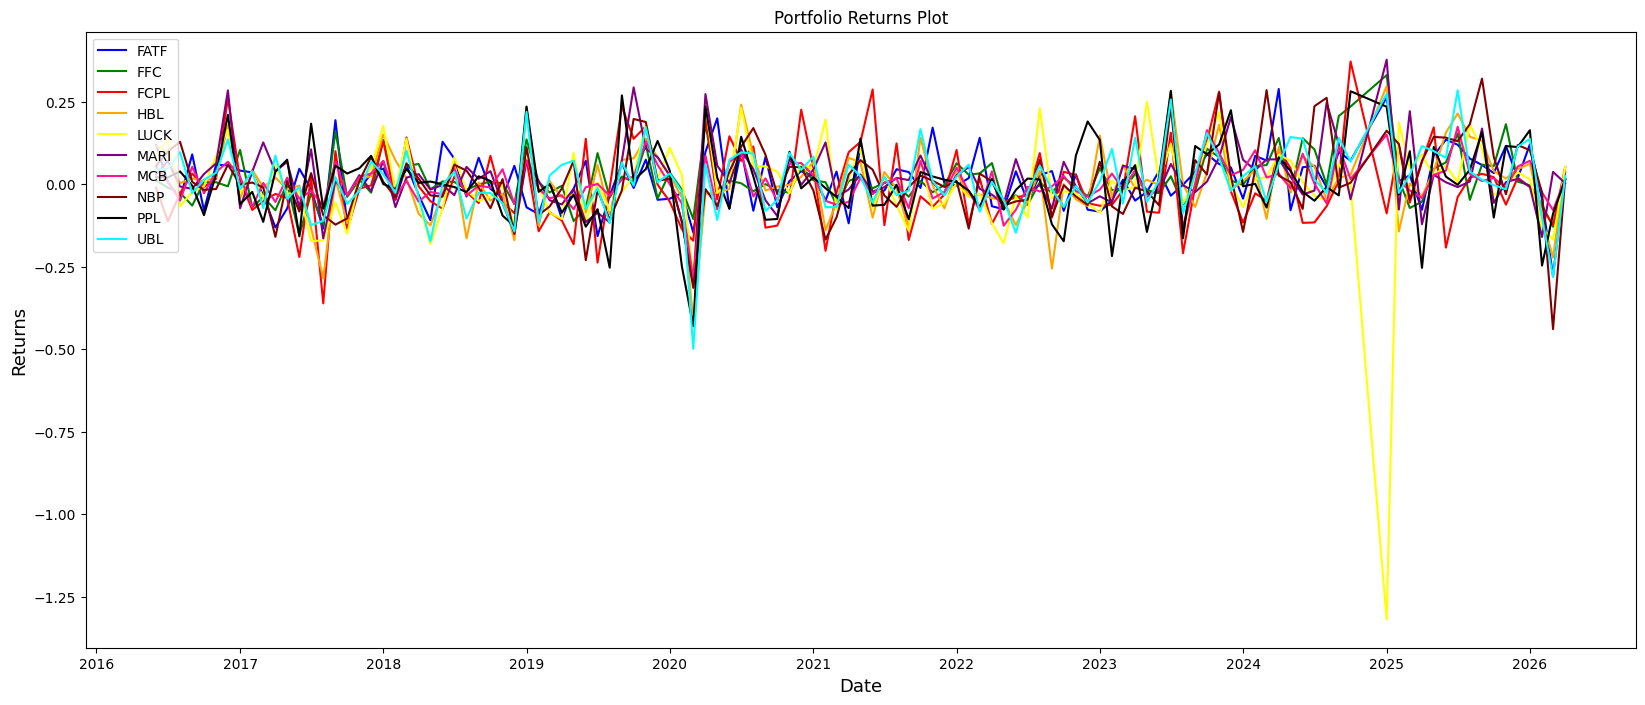

In [6]:
colors = ['blue', 'green', 'red', 'orange', 'yellow', 'purple', 'deeppink', 'maroon', 'black', 'cyan']

plt.figure(figsize=(20,8))
plt.title('Portfolio Returns Plot')

# Loop through the assets and plot each one with the corresponding color
for i, c in enumerate(assets):
    plt.plot(logReturns[c], label=c, color=colors[i])

plt.xlabel('Date', fontsize=13)
plt.ylabel('Returns', fontsize=13)
plt.legend(returns.columns.values, loc='upper left')

### Optimization

In [7]:
np.random.seed(1000)

NoPortfolios= 50000
 # Initialize the vectors (first filled with zeros)
weight= np.zeros((NoPortfolios, 10)) 
expReturn= np.zeros(NoPortfolios)
expVolatility= np.zeros(NoPortfolios)
sharpeRatio= np.zeros(NoPortfolios)

meanLogReturn= (logReturns).mean() * 252
cov= logReturns.cov() 
 # Done at the start since its common to iteration

# Risk-free rate for Pakistan Stock Exchange (approximately 6% annual)
risk_free_rate = 0.06

for k in range(NoPortfolios):
 # Random weight vector
    w= np.array(np.random.random(10)) # generate an array of 10 random values 
    w= w/np.sum(w) # Normalise the weights such that they add up to one
    weight[k,:]= w # In order to index each individual portflio(k)
 # Expected log return of Portfolio
    expReturn[k]= np.sum(meanLogReturn * w)
 # Volatility of Portfolio
    expVolatility[k]= np.sqrt(np.dot(w.T, np.dot(cov, w))) * 252
    # Transposed weights * cov matrix * weights
 # Sharpe Ratio  
    sharpeRatio[k]= (expReturn[k]- risk_free_rate)/expVolatility[k]

In [8]:
meanLogReturn

FATF    3.117491
FFC     3.152065
FCPL   -1.606427
HBL     0.862647
LUCK   -0.985735
MARI    4.422564
MCB     1.267158
NBP     2.461636
PPL     1.303488
UBL     2.997539
dtype: float64

In [9]:
np.mean(np.exp(meanLogReturn))

np.float64(17.121976809850633)

In [10]:
expVolatility

array([18.47463402, 17.35293866, 17.70372186, ..., 16.95312127,
       16.09404513, 18.15980876], shape=(50000,))

In [11]:
## Sharpe Ratio Maximization
maxIndex= sharpeRatio.argmax()
print('Optimal Weights:', weight[maxIndex, :])
print('Sharpe Ratio:', sharpeRatio.max())
print()
print('Expected Annualized Return', expReturn[maxIndex])
print('Annualized Volatility', expVolatility[maxIndex])

Optimal Weights: [0.0611698  0.19780338 0.00982807 0.02711531 0.06123997 0.42557456
 0.04367026 0.00762691 0.04048491 0.12548682]
Sharpe Ratio: 0.1841890840249323

Expected Annualized Return 3.146587747967051
Annualized Volatility 16.757712675031506


In [12]:
np.sum(weight[maxIndex, :])

np.float64(1.0000000000000002)

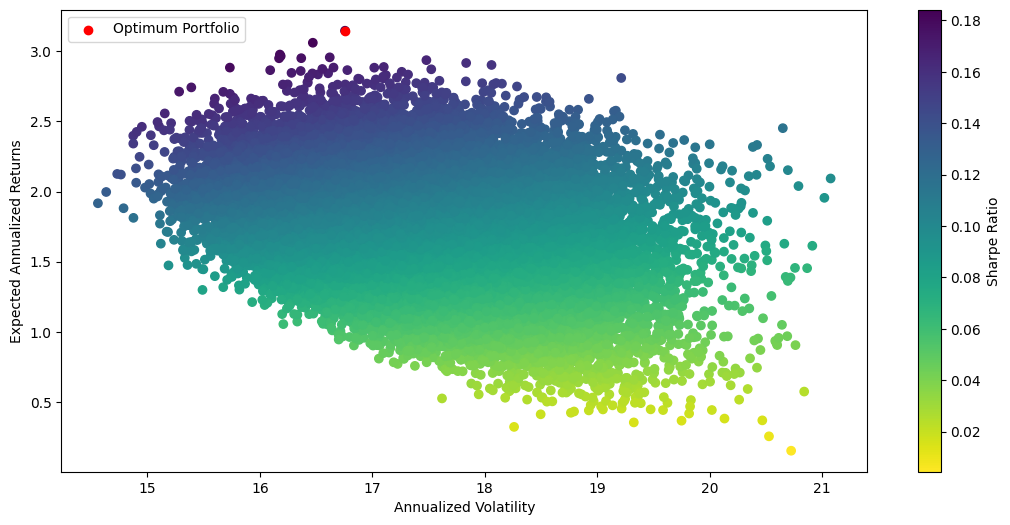

In [13]:
## Plotting the frontier
plt.figure(figsize= (13,6))
plt.scatter(expVolatility, expReturn, c= sharpeRatio, cmap= 'viridis_r')

plt.xlabel('Annualized Volatility')
plt.ylabel('Expected Annualized Returns')
plt.colorbar(label= 'Sharpe Ratio') # Label Bar
plt.scatter(expVolatility[maxIndex], expReturn[maxIndex], c= 'red', label= 'Optimum Portfolio')
plt.legend(loc= 'upper left')


In [14]:
expReturn[maxIndex]

np.float64(3.146587747967051)

In [15]:
np.mean(cov)

np.float64(0.004513430900231022)

In [16]:
cov

,FATF,FFC,FCPL,HBL,LUCK,MARI,MCB,NBP,PPL,UBL
FATF,0.007420,0.003045,0.002652,0.003663,-0.000237,0.002445,0.002196,0.003243,0.003388,0.003018
FFC,0.003045,0.005554,0.003213,0.003937,-0.001267,0.002582,0.002936,0.003099,0.003705,0.003788
FCPL,0.002652,0.003213,0.014567,0.004573,0.005524,0.003285,0.003439,0.004630,0.006225,0.004442
HBL,0.003663,0.003937,0.004573,0.011474,0.002720,0.004723,0.004816,0.006968,0.006787,0.008434
LUCK,-0.000237,-0.001267,0.005524,0.002720,0.024696,-0.000418,0.001578,0.003596,0.001279,0.002528
MARI,0.002445,0.002582,0.003285,0.004723,-0.000418,0.008897,0.002677,0.004098,0.006658,0.003788
MCB,0.002196,0.002936,0.003439,0.004816,0.001578,0.002677,0.004424,0.003658,0.004170,0.005011
NBP,0.003243,0.003099,0.004630,0.006968,0.003596,0.004098,0.003658,0.012666,0.005433,0.006271
PPL,0.003388,0.003705,0.006225,0.006787,0.001279,0.006658,0.004170,0.005433,0.013969,0.006305
UBL,0.003018,0.003788,0.004442,0.008434,0.002528,0.003788,0.005011,0.006271,0.006305,0.010473
